In [244]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('seaborn-v0_8-dark')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (14, 9),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC")

import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [245]:
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondStructure import FixedRateBondStructure, FixedRateBondStructureFunctionMap
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue, FixedRateBondValueFunctionMap

from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapStructure import IRSwapStructure
from Query.IRSwaps.IRSwapValue import IRSwapValue

from TB.FixedRateBondsTB import FixedRateBondsTB
from TB.IRSwapsTB import IRSwapsTB
from TB.TimeseriesBuilder import TimeseriesBuilder

In [246]:
tb = TimeseriesBuilder(
    irswaps_tb=IRSwapsTB(mdp=IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC")),
    fixedratebonds_tb=FixedRateBondsTB(mdp=FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-QL")),
)

In [280]:
end = datetime.date(2025, 10, 17)
start = end - datetime.timedelta(days=360) 

df = tb.get_timeseries(
    start=start,
    end=end,
    queries=[
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT30", value=IRSwapValue.MMSS),
        IRSwapQuery(curve="USD-SOFR-1D", tenor="CT2", value=IRSwapValue.MMSS),
        IRSwapQuery(curve="USD-SOFR-1D", tenor="CT3", value=IRSwapValue.MMSS),
        IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5/CT30", value=IRSwapValue.MMSS),
        
		# IRSwapQuery(curve="USD-SOFR-1D", tenor="30Y", value=IRSwapValue.SPREADOVER),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="5Y", value=IRSwapValue.SPREADOVER),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="7Y", value=IRSwapValue.SPREADOVER),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="5Y/30Y", value=IRSwapValue.SPREADOVER),
        
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT7", value=IRSwapValue.MMSS),
		# IRSwapQuery(curve="USD-SOFR-1D", tenor="CT10", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5/CT10", value=IRSwapValue.MMSS),
        # IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5/CT7/CT10", value=IRSwapValue.MMSS),
        
		IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5", value=IRSwapValue.MMSS),
        IRSwapQuery(curve="USD-SOFR-1D", tenor="CT30", value=IRSwapValue.MMSS),
        IRSwapQuery(curve="USD-SOFR-1D", tenor="CT5/CT30", value=IRSwapValue.MMSS),
        IRSwapQuery(curve="USD-SOFR-1D", tenor="CT2/CT5/CT7", value=IRSwapValue.MMSS),
    ],
    n_jobs=1,
    # ignore_cache=True
)
df

PRICING USD-SOFR-1D IRSWAPS...: 100%|██████████| 7/7 [00:00<00:00, 70.12it/s]
PRICING FIXED-RATE BONDS.: 0it [00:00, ?it/s]


SWAPSPREADS                                \
           USD-SOFR-1D CT2 OUTRIGHT MMSS USD-SOFR-1D CT3 OUTRIGHT MMSS   
Date                                                                     
2024-10-22                    -18.279040                    -23.283106   
2024-10-23                    -17.074271                    -23.279944   
2024-10-24                    -21.057413                    -26.160209   
2024-10-25                    -21.719684                    -26.410698   
2024-10-28                    -21.847300                    -25.739906   
...                                  ...                           ...   
2025-10-10                    -22.009044                    -27.314588   
2025-10-14                    -22.461753                    -27.341644   
2025-10-15                    -23.500805                    -28.605408   
2025-10-16                    -20.165268                    -24.593131   
2025-10-17                    -21.808702                    -26.220142   

                                                                         \
           USD-SOFR-1D CT5 OUTRIGHT MMSS USD-SOFR-1D CT30 OUTRIGHT MMSS   
Date                                                                      
2024-10-22                    -31.690371                     -82.393892   
2024-10-23                    -31.511490                     -82.566448   
2024-10-24                    -33.594871                     -83.070391   
2024-10-25                    -34.431905                     -84.026577   
2024-10-28                    -34.695099                     -83.036618   
...                                  ...                            ...   
2025-10-10                    -34.755911                     -76.216438   
2025-10-14                    -33.360743                     -74.566576   
2025-10-15                    -34.423807                     -74.603273   
2025-10-16                    -30.484968                     -71.538932   
2025-10-17                    -32.209148                     -72.610797   

                                                                             
           USD-SOFR-1D CT5/CT30 CURVE MMSS USD-SOFR-1D CT2/CT5/CT7 FLY MMSS  
Date                                                                         
2024-10-22                      -50.703521                        -4.403310  
2024-10-23                      -51.054958                        -5.340305  
2024-10-24                      -49.475520                        -3.816586  
2024-10-25                      -49.594673                        -3.800340  
2024-10-28                      -48.341519                        -4.326279  
...                                    ...                              ...  
2025-10-10                      -41.460527                        -5.339113  
2025-10-14                      -41.205833                        -3.633411  
2025-10-15                      -40.179466                        -3.894023  
2025-10-16                      -40.953964                        -3.459550  
2025-10-17                      -40.401648                        -3.559169  

[247 rows x 6 columns]

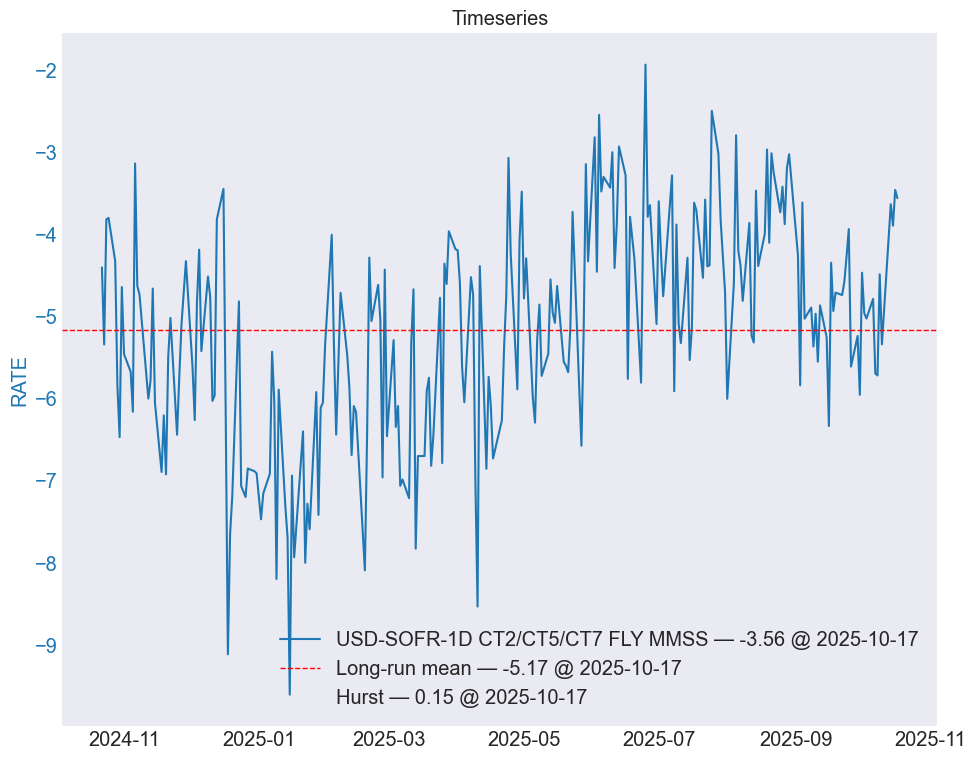

In [281]:
from RVUtils.plt_timeseries import make_secondary_axis_plot

plot, fig, ax, ax2, legend = make_secondary_axis_plot(ylabel_left="RATE", ylabel_right="RATE", title="Timeseries")

# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT2 OUTRIGHT MMSS"], which="left")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT3 OUTRIGHT MMSS"], which="left")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT5 OUTRIGHT MMSS"], which="left")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT5/CT7/CT10 FLY MMSS"], which="right")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D 2Y/5Y/7Y FLY SPREADOVER"], which="right")

# plot(df["SWAPSPREADS"]["USD-SOFR-1D 30Y OUTRIGHT SPREADOVER"], which="left")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D 5Y OUTRIGHT SPREADOVER"], which="right")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D 5Y OUTRIGHT SPREADOVER"], which="right")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT5 OUTRIGHT MMSS"], which="left")
# plot(df["SWAPSPREADS"]["USD-SOFR-1D CT30 OUTRIGHT MMSS"], which="right")

plot(
    df["SWAPSPREADS"]["USD-SOFR-1D CT2/CT5/CT7 FLY MMSS"],
    which="left",
    indicators=[
        # {"kind": "last", "style": {"linestyle": "--", "linewidth": 1.2, "color": "tab:purple"}},  
        # {"kind": "ema", "window": 20, "style": {"linestyle": "--", "color": "red"}},
        {"kind": "simple_avg", "label": "Long-run mean", "style": {"linestyle": "--", "color": "red"}},
		{"kind": "hurst", "hide": True}
    ],
    # ou={"enable": True, "steps": 126, "add_metrics_to_legend": True}
)

# plot(df["IRS"]["USD-SOFR-1D 5Y OUTRIGHT RATE"])
# plot(df["IRS"]["USD-SOFR-1D 10Y OUTRIGHT RATE"])
# plot(df["IRS"]["USD-SOFR-1D 30Y OUTRIGHT RATE"])
# plot(df["IRS"]["USD-SOFR-1D 2Y OUTRIGHT RATE"])

legend(show_date=True)
plt.show()


# plt.plot(df.index, df["SWAPSPREADS"]["USD-SOFR-1D CT30 OUTRIGHT SPREADOVER"])

Beta: [0.08399957 1.09890109]
Beta Std Error: [0.08790107 0.09257269]
Beta Covariance: [[124322.06662226  -7753.74520641]
 [ -7753.74520641 137887.75470735]]
Residual Variance: 6.214985189555512e-08
Inverse Condition #: 0.9393192677991661
Reason(s) for Halting:
  Sum of squares convergence


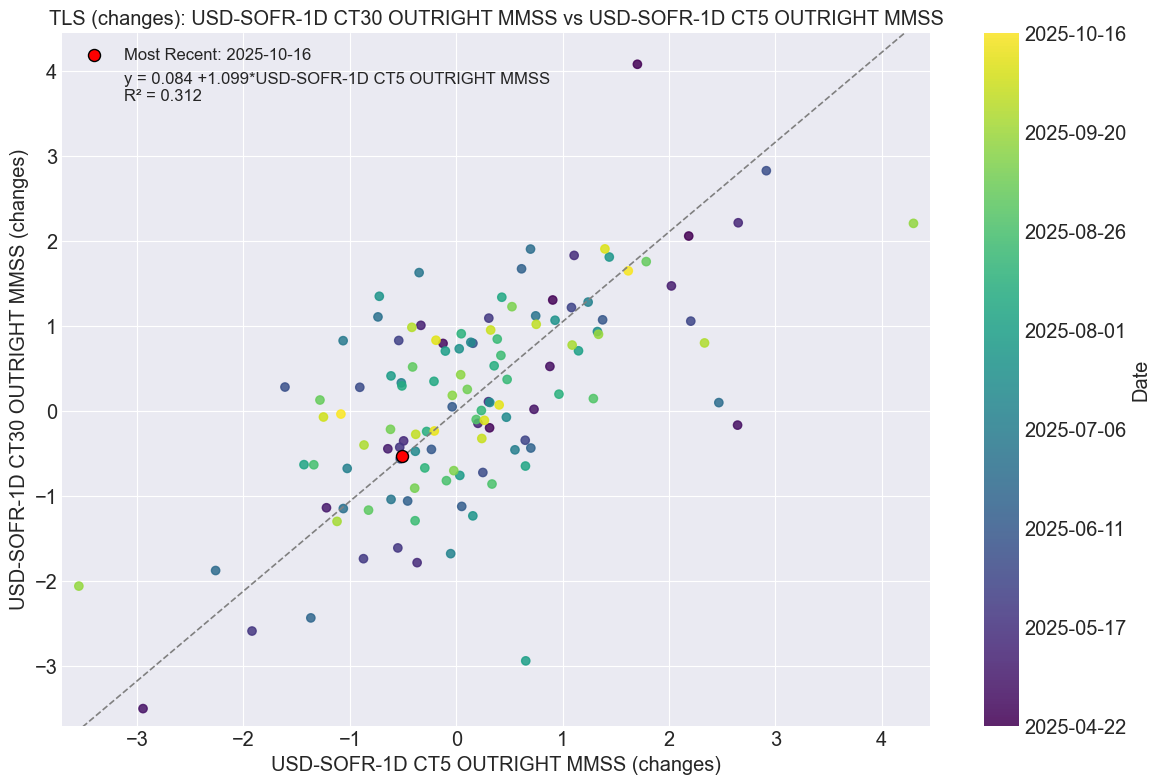

In [212]:
# from RVUtils.regression import make_linear_regression_builder
# from RVUtils.arbl_hedge_ratios import get_tls_hedge_ratio

# add_x, fit, plot_avp, plot_resid, plot_resid_ts, get_data = make_linear_regression_builder(
#     df=df["SWAPSPREADS"], y_col="USD-SOFR-1D CT30 OUTRIGHT MMSS", date_color_bar=True, on_diff=True
# )
# add_x("USD-SOFR-1D CT5 OUTRIGHT MMSS")

# res = fit(model="TLS", verbose=True)
# plot_avp()
# # plot_resid_ts(
# #     # plot_zscores=True,
# #     # stds=(1, 2),
# #     ou_bands=True,
# #     ou_steps=126,
# # )

from RVUtils.regression import make_linear_regression_builder
import gs_quant.timeseries.econometrics as gsqtse

add_x, fit_, plot_avp, plot_resid, plot_resid_ts, get_data = make_linear_regression_builder(
    df=df["SWAPSPREADS"],
    y_col="USD-SOFR-1D CT30 OUTRIGHT MMSS",
    date_color_bar=True,
    on_diff=True,
    add_constant=True,
)

add_x("USD-SOFR-1D CT5 OUTRIGHT MMSS")
_ = fit_(model="OLS")
X_used, y_used, _ = get_data()
X_no_const = X_used.drop(columns=["const"], errors="ignore")

def rvol_abs(s, w=60, floor=1e-8):
    v = gsqtse.volatility(x=s, w=w, returns_type=gsqtse.Returns.ABSOLUTE)
    return v.reindex(y_used.index).bfill().clip(lower=floor)

sx = np.column_stack([rvol_abs(X_no_const[c]).values for c in X_no_const.columns])
sy = rvol_abs(y_used).values

res_deming = fit_(model="TLS", tls_x_errs=sx, tls_y_errs=sy, verbose=True)
plot_avp()

In [223]:
import gs_quant.timeseries
import gs_quant.timeseries.econometrics as gsqtse

gsqtse.Returns.ABSOLUTE

# gsqtse.volatility(x=df["SWAPSPREADS"]["USD-SOFR-1D CT5/CT30 CURVE MMSS"], w=60, returns_type=gsqtse.Returns.ABSOLUTE).tail(1) / 100

gsqtse.volatility(x=df["SWAPSPREADS"]["USD-SOFR-1D CT5 OUTRIGHT MMSS"], w=60, returns_type=gsqtse.Returns.ABSOLUTE).tail(1) / 100 / np.sqrt(252)

Date
2025-10-16    0.987696
Name: USD-SOFR-1D CT5 OUTRIGHT MMSS, dtype: float64